# Objective: plot the diffraction pattern of specific shapes through a circular aperture

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from scipy.special import j1 #bessel function
from scipy.optimize import brentq

In [ ]:
# Search for the hm point in the sinc function
def g(t):
    return np.sinc(t)**2 - 0.5

# search for the root between 0 (peak) and 1 (first zero of sinc)
t0 = brentq(g, 1e-6, 1.0)

print(f"t0 = {t0}")

t0 = 0.4429464706894524


In [ ]:
# Functions
def top_hat(x, r):
    return np.where((x>= -r) & (x <= r), 1, 0)

def fwhm_to_w_gaus(fwhm):
    # convert fwhm to beam waist
    return fwhm / np.sqrt(2 * np.log(2))
    
def gaussian_profile(x, w):
    # z - radial distance from center
    # w - beam radius (I = 1/e**2)
    gaus =  np.exp(-2*x**2/w**2)
    #normalize to preserve energy 
    gaus_norm = gaus/np.max(gaus)
    return gaus

def sinc2_profile(x, fwhm_psf):
    t0 = 0.443
    s = np.sinc(x*t0/(0.5*fwhm_psf))**2
    s_norm = s/np.max(s)
    return s_norm
    

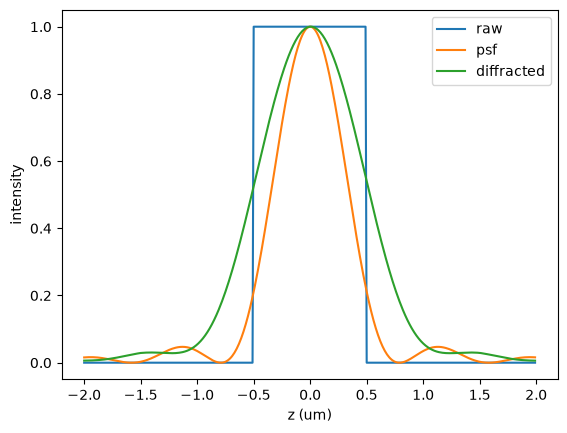

In [41]:
# Parameters
r = 0.5 # lipid radius (um)
psf_fwhm_lateral = 0.2 # theoretical lateral resolution (um)
psf_fwhm_axial = 0.7 #theoretical axial resolution (um)
w_lateral = fwhm_to_w_gaus(psf_fwhm_lateral)
w_axial = fwhm_to_w_gaus(psf_fwhm_axial)

dz = 0.01 # um

# axial simulation
z_range = np.arange(-2, 2, dz)

# create tophat
tophat = top_hat(z_range, r)

# make psf 
psf_axial = sinc2_profile(z_range, psf_fwhm_axial)

# convolve sphere with psf
diffraction_pattern = fftconvolve(tophat, psf_axial, mode="same")
diffraction_pattern /= np.max(diffraction_pattern)

plt.figure()
plt.plot(z_range, tophat, label='raw')
plt.plot(z_range, psf_axial, label='psf')
plt.plot(z_range, diffraction_pattern, label='diffracted')
plt.xlabel("z (um)")
plt.ylabel("intensity")
plt.legend()
plt.show()

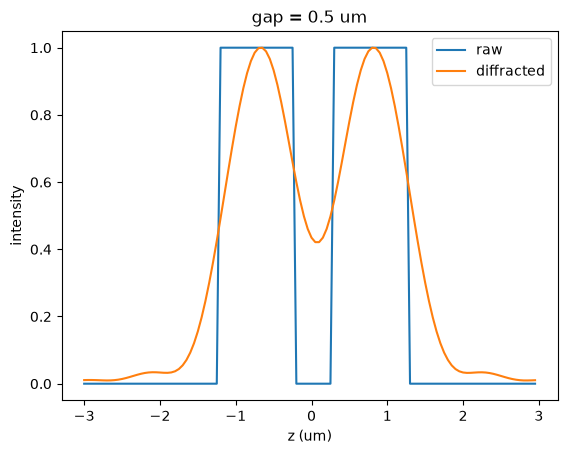

In [ ]:
# two spheres next to each other
dz = 0.05
z_range = np.arange(-3, 3, dz)
psf_axial = sinc2_profile(z_range, psf_fwhm_axial)
gap = 0.5 #um
raw_profile = np.zeros_like(z_range)
raw_profile = raw_profile + top_hat(z_range - (r+gap/2), r) + top_hat(z_range + (r+gap/2), r)

diffraction_pattern = fftconvolve(raw_profile, psf_axial, mode="same")
diffraction_pattern /= np.max(diffraction_pattern)

plt.figure()
# plt.plot(z_range, psf_axial, label='psf')
plt.plot(z_range, raw_profile, label='raw')
plt.plot(z_range, diffraction_pattern, label='diffracted')
plt.xlabel("z (um)")
plt.ylabel("intensity")
plt.title(f'gap = {gap} um')
plt.legend()
plt.show()

In [70]:
# finding the dip in contrast in the middle
from scipy.signal import find_peaks

min_dip = 0.265 # based on rayleigh

def find_dip(z, threshold = 0.5):
    peaks, properties = find_peaks(z, height = threshold)
    # print(peaks)
    peak_values = z[peaks]
    peak_positions = z[peaks] 
    # print(peak_values)
    # print(peak_positions[1])

    dip_region = z[peaks[0]:peaks[1]+1]
    local_min_idx = np.argmin(dip_region) + peaks[0]
    local_min_val = z[local_min_idx]
    local_min_z = z[local_min_idx]
    # print("z at true local min:", local_min_z)
    # print("intensity at true local min:", local_min_val)
    contrast_dif = peak_values[0] - local_min_val/peak_values[0]
    # print("contrast dif: ", contrast_dif)
    return local_min_val, local_min_idx, contrast_dif 

diff_pattern_dip_val, diff_pattern_dip_loc, diff_pattern_dip = find_dip(diffraction_pattern)
print(diff_pattern_dip, ", min dip: ", min_dip)


0.5787190310142385 , min dip:  0.265
